In [3]:
# =========================================
# 1. IMPORTS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [41]:
# =========================================
# 2. LOAD DATA
# =========================================
file_path = "Data/PM25-DATA-2022-2024.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Shape: (275170, 2)


,Time,Particulas_PM25
0,2022-03-04 11:51:35,6 μg/m³
1,2022-03-04 11:56:35,3 μg/m³
2,2022-03-04 12:01:36,4 μg/m³
3,2022-03-04 12:06:36,4 μg/m³
4,2022-03-04 12:11:36,3 μg/m³


In [42]:
# =========================================
# 3. BASIC INFO
# =========================================
df.info()

print("\nValores nulos:")
print(df.isnull().sum())

print("\nDuplicados:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 275170 entries, 0 to 275169
Data columns (total 2 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   Time             275170 non-null  str  
 1   Particulas_PM25  275170 non-null  str  
dtypes: str(2)
memory usage: 4.2 MB

Valores nulos:
Time               0
Particulas_PM25    0
dtype: int64

Duplicados: 7


In [43]:
# =========================================
# 4. DATA CLEANING
# =========================================

# Convertir fecha
df["Time"] = pd.to_datetime(df["Time"], errors="coerce")

# Limpiar PM2.5 (quitar "μg/m³")
df["PM25"] = (
    df["Particulas_PM25"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
)

df["PM25"] = pd.to_numeric(df["PM25"], errors="coerce")

# Eliminar filas inválidas
df = df.dropna(subset=["Time", "PM25"])

# Eliminar duplicados
df = df.drop_duplicates()

# Ordenar por tiempo
df = df.sort_values("Time")

df.head()

,Time,Particulas_PM25,PM25
0,2022-03-04 11:51:35,6 μg/m³,6
1,2022-03-04 11:56:35,3 μg/m³,3
2,2022-03-04 12:01:36,4 μg/m³,4
3,2022-03-04 12:06:36,4 μg/m³,4
4,2022-03-04 12:11:36,3 μg/m³,3


In [44]:
# =========================================
# 5. FEATURE ENGINEERING
# =========================================
df["year"] = df["Time"].dt.year
df["month"] = df["Time"].dt.month
df["day"] = df["Time"].dt.day
df["hour"] = df["Time"].dt.hour

# Estacionalidad (Guatemala)
df["dry_season"] = df["month"].isin([11,12,1,2,3,4,5]).astype(int)

df.head()

,Time,Particulas_PM25,PM25,year,month,day,hour,dry_season
0,2022-03-04 11:51:35,6 μg/m³,6,2022,3,4,11,1
1,2022-03-04 11:56:35,3 μg/m³,3,2022,3,4,11,1
2,2022-03-04 12:01:36,4 μg/m³,4,2022,3,4,12,1
3,2022-03-04 12:06:36,4 μg/m³,4,2022,3,4,12,1
4,2022-03-04 12:11:36,3 μg/m³,3,2022,3,4,12,1


In [45]:
df = df.drop(columns='Time')
df = df.drop(columns='Particulas_PM25')
df = df.drop(columns='dry_season')
df.head()

,PM25,year,month,day,hour
0,6,2022,3,4,11
1,3,2022,3,4,11
2,4,2022,3,4,12
3,4,2022,3,4,12
4,3,2022,3,4,12


In [46]:

print(df.head())

   PM25  year  month  day  hour
0     6  2022      3    4    11
1     3  2022      3    4    11
2     4  2022      3    4    12
3     4  2022      3    4    12
4     3  2022      3    4    12


In [47]:
# =========================================
# 6. DESCRIPTIVE STATS
# =========================================
df["PM25"].describe()

count    275163.000000
mean         32.998437
std          49.126674
min           0.000000
25%           7.000000
50%          16.000000
75%          41.000000
max        1928.000000
Name: PM25, dtype: float64

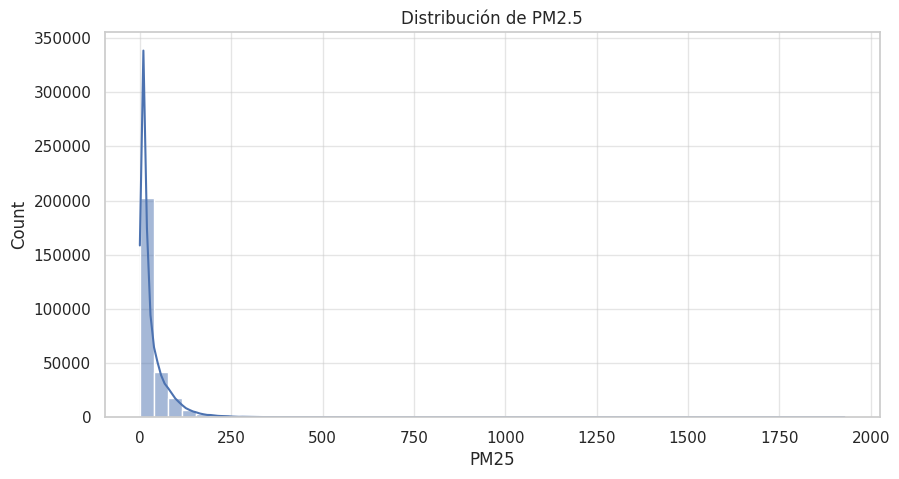

In [48]:
# =========================================
# 7. DISTRIBUTION
# =========================================
plt.figure(figsize=(10,5))
sns.histplot(df["PM25"], bins=50, kde=True)
plt.title("Distribución de PM2.5")
plt.show()

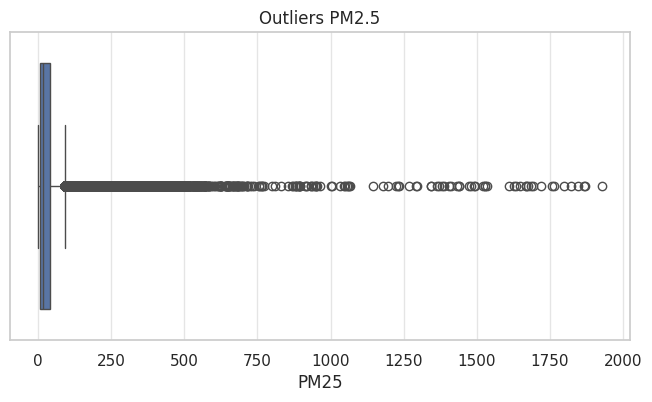

In [49]:
# =========================================
# 8. BOXPLOT
# =========================================
plt.figure(figsize=(8,4))
sns.boxplot(x=df["PM25"])
plt.title("Outliers PM2.5")
plt.show()

In [50]:
# =========================================
# 9. TIME SERIES
# =========================================
plt.figure(figsize=(14,6))
plt.plot(df["Time"], df["PM25"], alpha=0.5)
plt.title("Serie temporal PM2.5 (alta frecuencia)")
plt.xlabel("Fecha")
plt.ylabel("PM2.5")
plt.show()

KeyError: 'Time'

<Figure size 1400x600 with 0 Axes>

In [ ]:
# =========================================
# 10. MONTHLY AGGREGATION
# =========================================
df_monthly = (
    df.set_index("Time")
      .resample("ME")["PM25"]
      .mean()
      .reset_index()
)

df_monthly.head()

In [ ]:
# =========================================
# 11. MONTHLY TREND
# =========================================
plt.figure(figsize=(12,5))
plt.plot(df_monthly["Time"], df_monthly["PM25"], marker="o")
plt.title("PM2.5 promedio mensual")
plt.show()

In [ ]:
# =========================================
# 12. HOURLY PATTERN
# =========================================
hourly = df.groupby("hour")["PM25"].mean()

plt.figure(figsize=(10,5))
hourly.plot()
plt.title("PM2.5 promedio por hora")
plt.xlabel("Hora del día")
plt.show()

In [ ]:
# =========================================
# 13. MONTHLY SEASONALITY (4 GRAPHS)
# =========================================

# Promedio mensual global
monthly_all = df.groupby("month")["PM25"].mean()

# Promedio por año
df_2022 = df[df["year"] == 2022]
df_2023 = df[df["year"] == 2023]
df_2024 = df[df["year"] == 2024]

monthly_2022 = df_2022.groupby("month")["PM25"].mean()
monthly_2023 = df_2023.groupby("month")["PM25"].mean()
monthly_2024 = df_2024.groupby("month")["PM25"].mean()

# Crear figura con 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# ---- 2022 ----
axes[0,0].plot(monthly_2022.index, monthly_2022.values, marker="o")
axes[0,0].set_title("Promedio mensual PM2.5 (2022)")
axes[0,0].set_xlabel("Mes")

# ---- 2023 ----
axes[0,1].plot(monthly_2023.index, monthly_2023.values, marker="o")
axes[0,1].set_title("Promedio mensual PM2.5 (2023)")
axes[0,1].set_xlabel("Mes")
axes[0,1].set_ylabel("PM2.5")

# ---- 2024 ----
axes[1,0].plot(monthly_2024.index, monthly_2024.values, marker="o")
axes[1,0].set_title("Promedio mensual PM2.5 (2024)")
axes[1,0].set_xlabel("Mes")

# ---- Global ----
axes[1,1].plot(monthly_all.index, monthly_all.values, marker="o")
axes[1,1].set_title("Promedio mensual PM2.5 (2022-2024)")
axes[1,1].set_xlabel("Mes")
axes[1,1].set_ylabel("PM2.5")

plt.tight_layout()
plt.show()

In [12]:
file_path = "Data/Test/1.-base-anual_2024_insivumeh.xlsx"

df = pd.read_excel(file_path)
df.head(100)

,cod_depto,departamento,cod_mun,municipio,estacion,cod_mes,mes,variable,valor
0,4,Chimaltenango,401,Chimaltenango,Alameda ICTA,1,Enero,Precipitación,0.0
1,4,Chimaltenango,401,Chimaltenango,Alameda ICTA,1,Enero,Precipitación,0.0
2,4,Chimaltenango,401,Chimaltenango,Alameda ICTA,1,Enero,Precipitación,0.0
3,4,Chimaltenango,401,Chimaltenango,Alameda ICTA,1,Enero,Precipitación,0.0
4,4,Chimaltenango,401,Chimaltenango,Alameda ICTA,1,Enero,Precipitación,0.0
...,...,...,...,...,...,...,...,...,...
95,4,Chimaltenango,401,Chimaltenango,Alameda ICTA,1,Enero,Temperatura Mínima,11.4
96,4,Chimaltenango,401,Chimaltenango,Alameda ICTA,1,Enero,Temperatura Mínima,11.6
97,4,Chimaltenango,401,Chimaltenango,Alameda ICTA,1,Enero,Temperatura Mínima,7.0
98,4,Chimaltenango,401,Chimaltenango,Alameda ICTA,1,Enero,Temperatura Mínima,4.2


In [6]:
df.columns

Index(['cod_depto', 'departamento', 'cod_mun', 'municipio', 'estacion',
       'cod_mes', 'mes', 'variable', 'valor'],
      dtype='str')

In [9]:
valores_unicos = df["variable"].dropna().unique()

valores_unicos

<StringArray>
[      'Precipitación',   'Temperatura Media',  'Temperatura Máxima',
  'Temperatura Mínima',    'Humedad Relativa',        'Brillo solar',
 'Velocidad de viento',       'Brillo solar ', 'Presión Atmosférica',
 'Presión atmosférica', 'Dirección de viento']
Length: 11, dtype: str

# Precipitacion

In [16]:
filtro = (
    (df["municipio"] == "Guatemala") &
    (df["variable"] == "Precipitación") &
    (df["estacion"] == "INSIVUMEH")

)

df_filtrado = df[filtro]

df_filtrado.head(450)

,cod_depto,departamento,cod_mun,municipio,estacion,cod_mes,mes,variable,valor
16643,1,Guatemala,101,Guatemala,INSIVUMEH,1,Enero,Precipitación,0.0
16644,1,Guatemala,101,Guatemala,INSIVUMEH,1,Enero,Precipitación,0.0
16645,1,Guatemala,101,Guatemala,INSIVUMEH,1,Enero,Precipitación,0.0
16646,1,Guatemala,101,Guatemala,INSIVUMEH,1,Enero,Precipitación,0.0
16647,1,Guatemala,101,Guatemala,INSIVUMEH,1,Enero,Precipitación,0.0
...,...,...,...,...,...,...,...,...,...
112757,1,Guatemala,101,Guatemala,INSIVUMEH,12,Diciembre,Precipitación,0.0
112758,1,Guatemala,101,Guatemala,INSIVUMEH,12,Diciembre,Precipitación,0.0
112759,1,Guatemala,101,Guatemala,INSIVUMEH,12,Diciembre,Precipitación,0.0
112760,1,Guatemala,101,Guatemala,INSIVUMEH,12,Diciembre,Precipitación,0.0
